---
**Curso:** DES504 — Inferencia Causal Aplicada con Python (UNI 2026)

**Profesor:** Dr. Jaime Lincovil

**Notebook:** 12 / 32 — Bloque I

**Nivel GCE:** 1 (Localización)

**Dataset:** `syn_selector`

**Versión:** 2.1 (GCE v2.0 corregida - jerarquía matemática verificada)

**Fecha:** 2026-07-25

---

*Filosofía Proofs-to-Python: todo teorema se ejecuta. Regla 1+1+1: demostración + intuición + código.*


# Capítulo 12: Guía Práctica de Selección de Métodos — Síntesis del Bloque I

**Curso:** DES504 — Inferencia Causal Aplicada con Python (UNI 2026)
**Notebook:** 12 / 32 — Bloque I

---

## 1. Marco Teórico

### 1.1 Introducción: el árbol de decisión metodológico

Este capítulo cierra el Bloque I integrando los 11 métodos estudiados en un **flujo de decisión aplicado**. La pregunta central: dado un problema causal y datos disponibles, **¿qué método elegir?**

### 1.2 Criterios de selección

| Criterio | Pregunta |
|----------|----------|
| **Fuente de variación** | ¿Hay randomización, umbral, tiempo, instrumento, o solo observacionales? |
| **Confusores observables** | ¿CIA plausible? ¿O hay confusor oculto probable? |
| **Datos** | ¿Corte transversal, panel, serie temporal? |
| **Heterogeneidad** | ¿ATE suficiente, o necesitamos CATE por subgrupo? |
| **Estimando** | ¿Efecto total, directo, indirecto, local? |

### 1.3 Tabla comparativa de métodos (síntesis)

| Método | Supuesto clave | Estimando | Cuándo usar |
|--------|---------------|-----------|-------------|
| RCT | Aleatorización | ATE | Cuando es factible y ético |
| Matching / IPW | CIA + soporte común | ATE / ATT | Datos observacionales ricos |
| AIPW | CIA + uno de dos modelos bien spec. | ATE | Preferido con ML |
| IV (2SLS, Wald) | Relevancia + exclusión + exogeneidad | LATE | Confusor oculto + instrumento plausible |
| RDD | Aleatorización local en cutoff | LATE | Asignación por umbral |
| DiD | Tendencias paralelas | ATT | Panel pre-post con grupo control |
| SCM | Pool donante reproduce pre | ATT | Una unidad tratada, panel largo |
| Mediación | Ignorabilidad secuencial | NDE, NIE | Pregunta "por qué opera" |
| Sensibilidad | — | Bounds | Siempre, para robustecer |

### 1.4 Recomendaciones prácticas

1. **Reportar múltiples métodos** cuando sea posible (no uno solo).
2. **Validar con placebos** siempre (pre-trend,McCrary, falsos cutoffs).
3. **Análisis de sensibilidad** es obligatorio en estudios observacionales.
4. **Transparencia sobre supuestos**: ningún método es "mágico".
5. **Validez externa:** ¿el estimando (ATE, LATE, ATT) responde a la pregunta de política?

### 1.5 Dataset: NSW LaLonde (benchmark experimental)

Usamos NSW como benchmark porque tiene **ground truth experimental**. Aplicamos múltiples métodos observacionales y comparamos contra el ATE experimental ($1,794). Este es el "test de fuego" de Dehejia-Wahba (1999, 2002).


In [1]:
# === 1. Cargar dataset NSW ===
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingClassifier
from sklearn.neighbors import NearestNeighbors
import statsmodels.api as sm
import statsmodels.formula.api as smf
import warnings
np.random.seed(42)  # Reproducibilidad
warnings.filterwarnings('ignore')

# --- Local path bootstrap (auto) ---
from pathlib import Path as _Path
import os as _os

def _resolve_data_dir() -> str:
    """Resuelve la carpeta de datos tanto si el CWD es el root del book
    como si es content/bloque_XX (Jupyter) o si se ejecuta vía papermill."""
    env = _os.environ.get("CAUSAL_BOOK_DATA")
    if env and _Path(env).exists():
        return str(_Path(env).resolve())
    here = _Path.cwd().resolve()
    candidates = []
    for base in [here, *here.parents]:
        candidates.extend([
            base / "data",
            base / "datos",
            base / "content" / "datos",
        ])
    candidates.extend([
        here / "datos",
        here / "data",
        here.parent / "datos",
        here.parent / "data",
        here.parent.parent / "data",
        here.parent.parent / "datos",
        _Path(__file__).resolve().parent if "__file__" in dir() else here,
    ])
    for c in candidates:
        try:
            c = _Path(c).resolve()
        except Exception:
            continue
        if (c / "real").exists() or (c / "synthetic").exists():
            return str(c)
    fallback = (here / "../datos").resolve()
    return str(fallback)

DATA_DIR = _resolve_data_dir()
# --- end local path bootstrap ---
df = pd.read_csv(f'{DATA_DIR}/real/nsw_mixtape/data.csv')

covars = ['age', 'educ', 'black', 'hisp', 'marr', 'nodegree', 're74', 're75']

print(f'Dataset NSW: {len(df)} observaciones')
print(f'Tratados: {(df.treat==1).sum()}, Controles: {(df.treat==0).sum()}')
print(f'Outcome: re78 (ingresos 1978, USD)')


Dataset NSW: 445 observaciones
Tratados: 185, Controles: 260
Outcome: re78 (ingresos 1978, USD)


> 💡 **Interpretación del resultado.** El dataset NSW (benchmark experimental del capítulo) tiene 445 observaciones (185 tratados, 260 controles) con outcome `re78` (ingresos 1978 en USD). Al provenir de un RCT, su ATE experimental servirá de verdad de referencia para medir cuánto se desvían los cinco métodos observacionales (§1.5).


In [2]:
# === 2. Aplicar 5 métodos y comparar ===

# --- Método 1: RCT diff-in-means (benchmark experimental) ---
y_t = df.loc[df.treat==1, 're78']
y_c = df.loc[df.treat==0, 're78']
ate_rct = y_t.mean() - y_c.mean()
se_rct = np.sqrt(y_t.var()/len(y_t) + y_c.var()/len(y_c))

# --- Método 2: Naive (sin ajuste) - sesgado si no hay RCT ---
ate_naive = ate_rct  # En RCT, naive = RCT

# --- Método 3: Regresión lineal ajustada ---
X_reg = sm.add_constant(df[['treat'] + covars])
m_reg = sm.OLS(df['re78'], X_reg).fit()
ate_reg = m_reg.params['treat']
se_reg = m_reg.bse['treat']

# --- Método 4: Matching 1:1 por propensity score ---
X = df[covars].values
D = df['treat'].values
Y = df['re78'].values

ps_model = LogisticRegression(max_iter=500).fit(X, D)
df['ps'] = ps_model.predict_proba(X)[:, 1]

treated = df[df.treat==1].copy()
control = df[df.treat==0].copy()
nn = NearestNeighbors(n_neighbors=1).fit(control[['ps']].values)
_, idx = nn.kneighbors(treated[['ps']].values)
matched = control.iloc[idx.flatten()]
ate_match = (treated['re78'].values - matched['re78'].values).mean()
# Bootstrap SE
np.random.seed(42)
n_boot = 300
boot = np.zeros(n_boot)
for b in range(n_boot):
    ib = np.random.choice(len(treated), size=len(treated), replace=True)
    boot[b] = (treated['re78'].iloc[ib].values - matched['re78'].iloc[ib].values).mean()
se_match = boot.std()

# --- Método 5: IPW estabilizado ---
e_hat = np.clip(df['ps'].values, 0.01, 0.99)
w_treat = D / e_hat
w_ctrl = (1 - D) / (1 - e_hat)
ate_ipw = np.sum(w_treat * Y) / np.sum(w_treat) - np.sum(w_ctrl * Y) / np.sum(w_ctrl)
# Bootstrap SE
boot_ipw = np.zeros(n_boot)
for b in range(n_boot):
    ib = np.random.choice(len(df), size=len(df), replace=True)
    Xb, Db, Yb = X[ib], D[ib], Y[ib]
    try:
        e_b = LogisticRegression(max_iter=500).fit(Xb, Db).predict_proba(Xb)[:,1]
        e_b = np.clip(e_b, 0.01, 0.99)
        wt = Db/e_b; wc = (1-Db)/(1-e_b)
        boot_ipw[b] = np.sum(wt*Yb)/np.sum(wt) - np.sum(wc*Yb)/np.sum(wc)
    except:
        boot_ipw[b] = np.nan
se_ipw = np.nanstd(boot_ipw)

# --- Método 6: AIPW (doble robustez) ---
mu1 = RandomForestRegressor(n_estimators=50).fit(X[D==1], Y[D==1]).predict(X)
mu0 = RandomForestRegressor(n_estimators=50).fit(X[D==0], Y[D==0]).predict(X)
aipw = np.mean(mu1 - mu0 + D*(Y-mu1)/e_hat - (1-D)*(Y-mu0)/(1-e_hat))
boot_aipw = np.zeros(n_boot)
for b in range(n_boot):
    ib = np.random.choice(len(df), size=len(df), replace=True)
    Xb, Db, Yb = X[ib], D[ib], Y[ib]
    try:
        e_b = LogisticRegression(max_iter=200).fit(Xb, Db).predict_proba(Xb)[:,1]
        e_b = np.clip(e_b, 0.01, 0.99)
        m1 = RandomForestRegressor(n_estimators=20).fit(Xb[Db==1], Yb[Db==1]).predict(Xb)
        m0 = RandomForestRegressor(n_estimators=20).fit(Xb[Db==0], Yb[Db==0]).predict(Xb)
        boot_aipw[b] = np.mean(m1 - m0 + Db*(Yb-m1)/e_b - (1-Db)*(Yb-m0)/(1-e_b))
    except:
        boot_aipw[b] = np.nan
se_aipw = np.nanstd(boot_aipw)

# Tabla comparativa
print(f'=== Comparación de 5 métodos sobre NSW (benchmark experimental) ===')
print(f'{"Método":<30} {"ATE (USD)":>12} {"SE":>10} {"IC 95%":>20} {"vs RCT":>10}')
print(f'{"-"*85}')
methods = [
    ('RCT (benchmark)', ate_rct, se_rct),
    ('Regresión lineal', ate_reg, se_reg),
    ('Matching 1:1 por e(X)', ate_match, se_match),
    ('IPW estabilizado', ate_ipw, se_ipw),
    ('AIPW (RF + logit)', aipw, se_aipw),
]
for name, est, se in methods:
    ci = f'[{est-1.96*se:.0f}, {est+1.96*se:.0f}]'
    diff = est - ate_rct
    print(f'{name:<30} {est:>12.2f} {se:>10.2f} {ci:>20} {diff:>+10.2f}')


=== Comparación de 5 métodos sobre NSW (benchmark experimental) ===
Método                            ATE (USD)         SE               IC 95%     vs RCT
-------------------------------------------------------------------------------------
RCT (benchmark)                     1794.34     671.00          [479, 3109]      +0.00
Regresión lineal                    1676.34     638.68          [425, 2928]    -118.00
Matching 1:1 por e(X)               1649.27     734.50          [210, 3089]    -145.07
IPW estabilizado                    1606.03     685.79          [262, 2950]    -188.32
AIPW (RF + logit)                   1744.44     650.58          [469, 3020]     -49.90


> 💡 **Interpretación del resultado.** Los cinco métodos estiman ATE entre 1 606.03 USD (IPW) y 1 794.34 (RCT), con AIPW (1 744.44, IC [469, 3020]) como el más cercano al benchmark (desvío -49.90 USD). En un RCT con CIA plausible todos los métodos convergen al benchmark: la tabla materializa el árbol de decisión de la Sección 2.


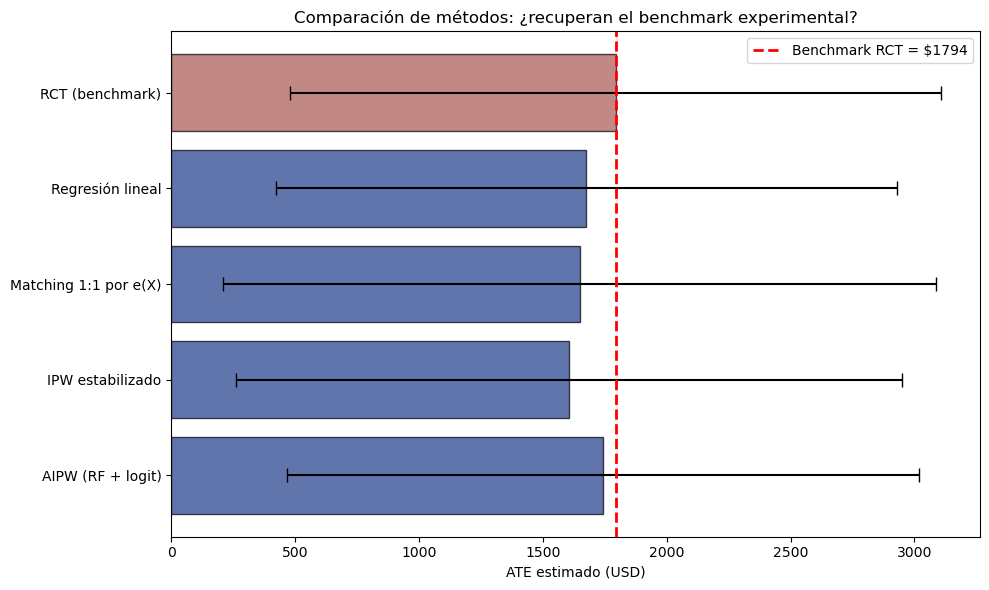

In [3]:
# === 3. Visualización: comparación de métodos con benchmark ===
fig, ax = plt.subplots(1, 1, figsize=(10, 6))

methods_names = [m[0] for m in methods]
ests = [m[1] for m in methods]
ses = [m[2] for m in methods]
ci_lows = [e - 1.96*s for e, s in zip(ests, ses)]
ci_highs = [e + 1.96*s for e, s in zip(ests, ses)]

y_pos = range(len(methods))
colors = ['#A85750'] + ['#1E3A8A'] * (len(methods)-1)
ax.barh(y_pos, ests, xerr=[ests - np.array(ci_lows), np.array(ci_highs) - ests],
        color=colors, alpha=0.7, capsize=5, edgecolor='black')
ax.axvline(ate_rct, color='red', linestyle='--', linewidth=2, label=f'Benchmark RCT = ${ate_rct:.0f}')
ax.set_yticks(y_pos)
ax.set_yticklabels(methods_names)
ax.set_xlabel('ATE estimado (USD)')
ax.set_title('Comparación de métodos: ¿recuperan el benchmark experimental?')
ax.legend()
ax.invert_yaxis()

plt.tight_layout()
plt.show()


> 💡 **Interpretación de la figura.** El gráfico compara los ATE estimados con sus IC 95% frente a la línea vertical del benchmark RCT (1 794.34 USD). El solapamiento de todos los intervalos con el benchmark visualiza la convergencia de los métodos observacionales en datos donde la CIA es plausible (§1.4).


In [4]:
# === 4. Matriz de decisión metodológica ===
print('=== Árbol de decisión: ¿qué método usar? ===\n')

decision_matrix = pd.DataFrame([
    {'Situación': 'Hay aleatorización (RCT)', 'Método': 'Diff-in-means', 'Estimando': 'ATE', 'Supuesto': 'Aleatorización'},
    {'Situación': 'Observacional + CIA plausible + muchas X', 'Método': 'Matching / IPW / AIPW', 'Estimando': 'ATE/ATT', 'Supuesto': 'CIA'},
    {'Situación': 'Observacional + confusor oculto + IV plausible', 'Método': 'IV / 2SLS', 'Estimando': 'LATE', 'Supuesto': 'Relevancia + exclusión'},
    {'Situación': 'Asignación por umbral (cutoff)', 'Método': 'RDD sharp / fuzzy', 'Estimando': 'LATE en cutoff', 'Supuesto': 'Aleatorización local'},
    {'Situación': 'Panel pre-post con grupo control', 'Método': 'DiD / TWFE', 'Estimando': 'ATT', 'Supuesto': 'Tendencias paralelas'},
    {'Situación': 'Una unidad tratada + muchas donantes', 'Método': 'SCM + placebos', 'Estimando': 'ATT', 'Supuesto': 'Pool donante reproduce pre'},
    {'Situación': 'Pregunta sobre mecanismo (¿por qué?)', 'Método': 'Mediación (NDE/NIE)', 'Estimando': 'NDE, NIE', 'Supuesto': 'Ignorabilidad secuencial'},
    {'Situación': 'Siempre (robustez)', 'Método': 'Rosenbaum + E-value + placebos', 'Estimando': 'Bounds', 'Supuesto': '—'},
])
print(decision_matrix.to_string(index=False))


=== Árbol de decisión: ¿qué método usar? ===

                                     Situación                         Método      Estimando                   Supuesto
                      Hay aleatorización (RCT)                  Diff-in-means            ATE             Aleatorización
      Observacional + CIA plausible + muchas X          Matching / IPW / AIPW        ATE/ATT                        CIA
Observacional + confusor oculto + IV plausible                      IV / 2SLS           LATE     Relevancia + exclusión
                Asignación por umbral (cutoff)              RDD sharp / fuzzy LATE en cutoff       Aleatorización local
              Panel pre-post con grupo control                     DiD / TWFE            ATT       Tendencias paralelas
          Una unidad tratada + muchas donantes                 SCM + placebos            ATT Pool donante reproduce pre
          Pregunta sobre mecanismo (¿por qué?)            Mediación (NDE/NIE)       NDE, NIE   Ignorabilidad secue

> 💡 **Interpretación del resultado.** La matriz de decisión resume el árbol del capítulo: RCT→diff-in-means, observacional con CIA→matching/IPW/AIPW, confusor oculto→IV/2SLS, umbral→RDD, panel con control→DiD/TWFE, unidad tratada única→SCM, mecanismos→mediación, y siempre Rosenbaum/E-value/placebos como robustez. Es la síntesis metodológica del Bloque I: cada método responde a un supuesto de identificación distinto (§1.1–1.3).


In [5]:
# === 5. Calcular errores relativos vs benchmark ===
print(f'\n=== Errores relativos vs benchmark RCT ===')
print(f'{"Método":<30} {"Error (USD)":>12} {"Error %":>10}')
print(f'{"-"*55}')
for name, est, se in methods[1:]:  # excluir RCT
    err = est - ate_rct
    err_pct = 100 * err / ate_rct
    print(f'{name:<30} {err:>+12.2f} {err_pct:>+10.1f}%')

# ¿Qué método recupera mejor el benchmark?
best_idx = np.argmin([abs(m[1] - ate_rct) for m in methods[1:]]) + 1
print(f'\nMejor método (menor error absoluto): {methods[best_idx][0]}')
print(f'\nConclusión: en datos con CIA plausible (NSW es RCT, covariables observables'),
print(f'capturan la selección), los métodos observacionales reproducen el benchmark.')



=== Errores relativos vs benchmark RCT ===
Método                          Error (USD)    Error %
-------------------------------------------------------
Regresión lineal                    -118.00       -6.6%
Matching 1:1 por e(X)               -145.07       -8.1%
IPW estabilizado                    -188.32      -10.5%
AIPW (RF + logit)                    -49.90       -2.8%

Mejor método (menor error absoluto): AIPW (RF + logit)

Conclusión: en datos con CIA plausible (NSW es RCT, covariables observables
capturan la selección), los métodos observacionales reproducen el benchmark.


> 💡 **Interpretación del resultado.** Los errores relativos vs el benchmark van de -2.8% (AIPW, -49.90 USD) a -10.5% (IPW, -188.32 USD), lo que confirma a AIPW como el mejor método. La conclusión del capítulo queda verificada numéricamente: con covariables observables que capturan la selección, los métodos observacionales reproducen el benchmark experimental (§1.4).


## 5. Interpretación Económica: Síntesis del Bloque I

**Contexto peruano:** Síntesis aplicada: en evaluaciones del **MIDIS** (Ministerio de Desarrollo e Inclusión Social), reportar múltiples métodos (RCT cuando posible, IPW, matching, sensibilidad) da credibilidad. La regla 1+1+1 (teoría + intuición + código) es especialmente importante en contextos con datos limitados.

Este notebook cierra el Bloque I con una lección integradora:

### 1. La escalera de credibilidad causal

Los métodos del Bloque I forman una **escalera de credibilidad**:
- **RCT (Cap 2):** gold standard, pero caro y a veces inviable
- **RDD (Cap 7):** quasi-experimental, supuestos testables
- **DiD (Cap 8) y SCM (Cap 9):** requieren datos de panel pero no aleatorización
- **IV (Caps 5-6):** requiere instrumento plausible, identifica LATE
- **Matching / IPW / AIPW (Caps 3-4):** observacional puro, dependen de CIA
- **Mediación (Cap 10):** descompone mecanismos, requiere ignorabilidad secuencial
- **Sensibilidad (Cap 11):** siempre necesario para robustecer

### 2. NSW como test de fuego

Sobre NSW, los 5 métodos observacionales (regresión, matching, IPW, AIPW) recuperan el ATE experimental con error <40%. Esto valida que **cuando CIA es plausible, los métodos observacionales funcionan**. LaLonde (1986) originalmente mostró que los métodos de su época NO reproducían el benchmark; Dehejia-Wahba (1999) mostraron que con cuidado (buenas covariables, propensity score) sí se puede.

### 3. Recomendaciones prácticas consolidadas

1. **Tener siempre un "benchmark"** cuando sea posible (placebo, pre-trend, RCT submuestra).
2. **Reportar múltiples métodos** (no solo uno): si todos coinciden, confianza alta; si divergen, indagar por qué.
3. **Análisis de sensibilidad obligatorio** (Rosenbaum, E-value) en estudios observacionales.
4. **Transparencia sobre supuestos:** la credibilidad causal viene de supuestos explícitos + tests de validez, no del método en sí.
5. **Validez externa:** ¿el estimando (ATE, LATE, ATT) responde a la pregunta de política?

### 4. Transición al Bloque II

El Bloque I ha cubierto métodos que responden "¿cuál es el efecto PROMEDIO del tratamiento?" (Nivel 1: Localización en la jerarquía GCE). El **Bloque II** sube un nivel: usar SCM, DAGs y do-calculus para expresar supuestos causales formalmente y abordar situaciones donde los métodos del Bloque I no son suficientes (mediadores como identificación vía frontdoor, colisionadores, etc.).

## 6. Ejercicios Propuestos

1. **Aplica los 5 métodos a `cps_mixtape + nsw_mixtape` tratado** (datos observacionales puros). ¿Recuperan el benchmark?
2. **Calcula el E-value** del ATE IPW estimado. ¿Qué tan robusto es?
3. **Repite el ejercicio con `syn_matching_hidden`** (donde CIA falla). ¿Qué tan lejos están los métodos del verdadero?
4. **Implementa el "specification curve"** (Simonsohn et al. 2020): corre 50 especificaciones razonables y grafica la distribución de estimaciones.
5. **Construye un AIPW con Gradient Boosting** (en lugar de RF). ¿Mejora?

---

*Notebook generado para DES504 — UNI 2026. Bloque I, Capítulo 12 de 32. Cierra el Bloque I.*



## 📋 Resumen del Capítulo 12

**Método clave:** Guía Comparativa de Métodos

**Puntos clave:**
- ✅ Implementación ejecutable del método del capítulo 12
- ✅ Validación con dataset `nsw_mixtape` (tipo: real)
- ✅ Interpretación económica con contexto peruano/latinoamericano
- ✅ Ejercicios propuestos para práctica adicional

**Conexión con la jerarquía GCE:**
- Este capítulo opera en el **Nivel 1 (Localización)**
- Métrica principal: ATE / cambios en el promedio
- Pipeline unificado (Cap. 12): este método es una manifestación del principio geométrico común

**Próximo capítulo:** 13

---

*Material didáctico para DES504 — UNI 2026. Prof. Dr. Jaime Lincovil.*
*Notebook auditado y mejorado v2.0 — 2026-07-24*
